In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
data = pd.read_csv("train.csv")

## Missing Values

In [3]:
# Handling missing values

#------missing indicators-------------
data['missing_sleep_duration'] = data['sleep_duration'].isnull().astype(int)
data['missing_heart_rate'] = data['heart_rate'].isnull().astype(int)
data['missing_bmi'] = data['bmi'].isnull().astype(int)
data['missing_calorie_expenditure'] = data['calorie_expenditure'].isnull().astype(int)
data['missing_step_count'] = data['step_count'].isnull().astype(int)
data['missing_exercise_duration'] = data['exercise_duration'].isnull().astype(int)
data['missing_water_intake'] = data['water_intake'].isnull().astype(int)
data['missing_diet_type'] = data['diet_type'].isnull().astype(int)
data['missing_stress_level'] = data['stress_level'].isnull().astype(int)
data['missing_sleep_quality'] = data['sleep_quality'].isnull().astype(int)
data['missing_physical_activity_level'] = data['physical_activity_level'].isnull().astype(int)
data['missing_smoking_alcohol'] = data['smoking_alcohol'].isnull().astype(int)
data['missing_gender'] = data['gender'].isnull().astype(int)

#------ fill missing values-----------
data['sleep_duration'] = data['sleep_duration'].fillna(data['sleep_duration'].median())
data['heart_rate'] = data['heart_rate'].fillna(data['heart_rate'].median())
data['bmi'] = data['bmi'].fillna(data['bmi'].median())
data['calorie_expenditure'] = data['calorie_expenditure'].fillna(data['calorie_expenditure'].median())
data['step_count'] = data['step_count'].fillna(data['step_count'].median())
data['exercise_duration'] = data['exercise_duration'].fillna(data['exercise_duration'].median())
data['water_intake'] = data['water_intake'].fillna(data['water_intake'].median())
data['diet_type'] = data['diet_type'].fillna(data['diet_type'].mode()[0])
data['stress_level'] = data['stress_level'].fillna(data['stress_level'].mode()[0])
data['sleep_quality'] = data['sleep_quality'].fillna(data['sleep_quality'].mode()[0])
data['physical_activity_level'] = data['physical_activity_level'].fillna(data['physical_activity_level'].mode()[0])
data['smoking_alcohol'] = data['smoking_alcohol'].fillna(data['smoking_alcohol'].mode()[0])
data['gender'] = data['gender'].fillna(data['gender'].mode()[0])


In [4]:
X = data.drop(columns = ['id','health_condition'])
y = data['health_condition']

In [5]:
#-----manual mapping--------
stress_mapping = {
    'low' : 0,
    'medium' : 1,
    'high' : 2
}
X['stress_level'] = X['stress_level'].map(stress_mapping)

sleep_mapping = {
    'poor' : 0,
    'average' : 1,
    'good' : 2
}
X['sleep_quality'] = X['sleep_quality'].map(sleep_mapping)

physical_mapping = {
    'sedentary' : 0,
    'moderate' : 1,
    'active' : 2
}
X['physical_activity_level'] = X['physical_activity_level'].map(physical_mapping)

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

## Encoding and Scaling

In [7]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#-----Label Encoding--------
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

#-----OHE------------
ohe = OneHotEncoder(
    drop = 'first',
    handle_unknown = 'ignore',
    sparse_output = False
)
encoded_train = ohe.fit_transform(X_train[['diet_type', 'smoking_alcohol', 'gender']])
encoded_train_data = pd.DataFrame(encoded_train, columns = ohe.get_feature_names_out(), index = X_train.index)

encoded_test = ohe.transform(X_test[['diet_type', 'smoking_alcohol', 'gender']])
encoded_test_data = pd.DataFrame(encoded_test, columns = ohe.get_feature_names_out(), index = X_test.index)

#-----------Scaling----------
X_train = X_train.drop(columns = ['diet_type', 'smoking_alcohol', 'gender'])
X_test = X_test.drop(columns = ['diet_type', 'smoking_alcohol', 'gender'])
scale = StandardScaler()
X_train_scaled = scale.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns, index = X_train.index)
X_test_scaled = scale.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns, index = X_test.index)

#-------------------------------------------------------------------------
X_train = pd.concat([X_train_scaled, encoded_train_data], axis = 1)
X_test = pd.concat([X_test_scaled, encoded_test_data], axis = 1)

## ANN

In [64]:
import torch
import torch.nn as nn
import torch.optim as optim

In [65]:
X_train_tensor = torch.tensor(X_train.to_numpy(), dtype = torch.float32)
y_train_tensor = torch.tensor(y_train, dtype = torch.long)

X_test_tensor = torch.tensor(X_test.to_numpy(), dtype = torch.float32)
y_test_tensor = torch.tensor(y_test, dtype = torch.long)

In [66]:
from torch.utils.data import DataLoader, TensorDataset

In [67]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size = 64)
test_loader = DataLoader(test_dataset, batch_size = 64)

## Building ANN

In [68]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 64),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(64,32),
            nn.ReLU(),

            # 3rd hidden layer
            nn.Linear(32,16),
            nn.ReLU(),

            # ouput layer
            nn.Linear(16,3)
        )

    def forward(self,x):
        return self.model(x)

In [69]:
model = ANN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

## Training loop

In [70]:
epochs = 40
train_loss = []
test_loss = []
best_validation = float('inf')
counter = 0
patience = 10

for epoch in range(epochs):
    # model training
    model.train()
    running_tloss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()

        output = model(xb)
        loss = criterion(output, yb)
        loss.backward()
        optimizer.step()

        running_tloss += loss.item()

    training_loss = running_tloss/len(train_loader)
    train_loss.append(training_loss)

    # validation
    model.eval()
    running_vloss = 0.0

    with torch.no_grad():
        for xb, yb in test_loader:
            output = model(xb)
            loss = criterion(output, yb)
            
            running_vloss += loss.item()

    validation_loss = running_vloss/len(test_loader)
    test_loss.append(validation_loss)

    print(f"for Epochs {epoch+1}/{epochs}, training loss : {training_loss:.5f}, Validation loss : {validation_loss:.5f}")
    if best_validation>validation_loss:
        best_validation = validation_loss
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0

    else:
        counter+=1
        print(f"No Improvement for counter {counter}")
        if counter >= patience:
            print("Early Stopping......")
            break

for Epochs 1/40, training loss : 0.12544, Validation loss : 0.10271
for Epochs 2/40, training loss : 0.10117, Validation loss : 0.09898
for Epochs 3/40, training loss : 0.09857, Validation loss : 0.09693
for Epochs 4/40, training loss : 0.09675, Validation loss : 0.09606
for Epochs 5/40, training loss : 0.09549, Validation loss : 0.09541
for Epochs 6/40, training loss : 0.09467, Validation loss : 0.09513
for Epochs 7/40, training loss : 0.09419, Validation loss : 0.09440
for Epochs 8/40, training loss : 0.09380, Validation loss : 0.09398
for Epochs 9/40, training loss : 0.09343, Validation loss : 0.09396
for Epochs 10/40, training loss : 0.09304, Validation loss : 0.09336
for Epochs 11/40, training loss : 0.09292, Validation loss : 0.09331
for Epochs 12/40, training loss : 0.09271, Validation loss : 0.09333
No Improvement for counter 1
for Epochs 13/40, training loss : 0.09250, Validation loss : 0.09367
No Improvement for counter 2
for Epochs 14/40, training loss : 0.09232, Validation 

In [71]:
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

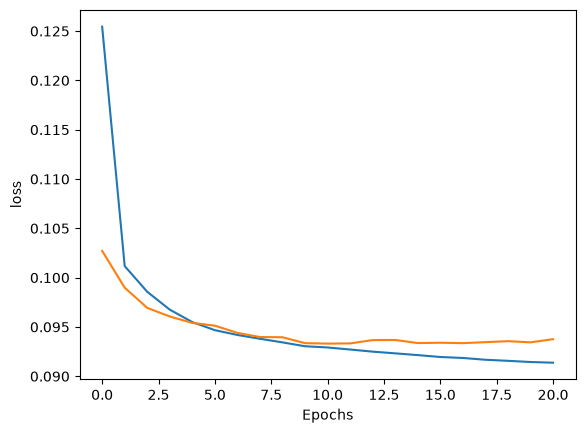

In [72]:
import matplotlib.pyplot as plt
df_loss = pd.DataFrame(
    {
        "Training loss" : train_loss,
        "Validation loss" : test_loss
    }
)
plt.plot(df_loss["Training loss"], label = "Training loss")
plt.plot(df_loss["Validation loss"], label = "Validation loss")

plt.xlabel("Epochs")
plt.ylabel("loss")
plt.show()

In [73]:
# Evaluation
from sklearn.metrics import balanced_accuracy_score
model.eval()
correct = 0
total = 0
all_pred = []
all_labels = []
with torch.no_grad():
    for xb, yb in test_loader:
        output = model(xb)
        predicated = torch.argmax(output, dim = 1)
    
        correct += (predicated == yb).sum().item()
        total+=yb.size(0)
    
        all_pred.extend(predicated.numpy())
        all_labels.extend(yb.numpy())

print(f"Accuracy:{correct/total}")
print(f"Balanced Accuracy : {balanced_accuracy_score(all_labels, all_pred)}")

Accuracy:0.9659319798866814
Balanced Accuracy : 0.8582706830757175


## Test data

In [74]:
tdata = pd.read_csv("test.csv")

In [75]:
test_id = tdata["id"]

In [76]:
# Handling missing values

#------missing indicators-------------
tdata['missing_sleep_duration'] = tdata['sleep_duration'].isnull().astype(int)
tdata['missing_heart_rate'] = tdata['heart_rate'].isnull().astype(int)
tdata['missing_bmi'] = tdata['bmi'].isnull().astype(int)
tdata['missing_calorie_expenditure'] = tdata['calorie_expenditure'].isnull().astype(int)
tdata['missing_step_count'] = tdata['step_count'].isnull().astype(int)
tdata['missing_exercise_duration'] = tdata['exercise_duration'].isnull().astype(int)
tdata['missing_water_intake'] = tdata['water_intake'].isnull().astype(int)
tdata['missing_diet_type'] = tdata['diet_type'].isnull().astype(int)
tdata['missing_stress_level'] = tdata['stress_level'].isnull().astype(int)
tdata['missing_sleep_quality'] = tdata['sleep_quality'].isnull().astype(int)
tdata['missing_physical_activity_level'] = tdata['physical_activity_level'].isnull().astype(int)
tdata['missing_smoking_alcohol'] = tdata['smoking_alcohol'].isnull().astype(int)
tdata['missing_gender'] = tdata['gender'].isnull().astype(int)

#------ fill missing values-----------
tdata['sleep_duration'] = tdata['sleep_duration'].fillna(tdata['sleep_duration'].median())
tdata['heart_rate'] = tdata['heart_rate'].fillna(tdata['heart_rate'].median())
tdata['bmi'] = tdata['bmi'].fillna(tdata['bmi'].median())
tdata['calorie_expenditure'] = tdata['calorie_expenditure'].fillna(tdata['calorie_expenditure'].median())
tdata['step_count'] = tdata['step_count'].fillna(tdata['step_count'].median())
tdata['exercise_duration'] = tdata['exercise_duration'].fillna(tdata['exercise_duration'].median())
tdata['water_intake'] = tdata['water_intake'].fillna(tdata['water_intake'].median())
tdata['diet_type'] = tdata['diet_type'].fillna(tdata['diet_type'].mode()[0])
tdata['stress_level'] = tdata['stress_level'].fillna(tdata['stress_level'].mode()[0])
tdata['sleep_quality'] = tdata['sleep_quality'].fillna(tdata['sleep_quality'].mode()[0])
tdata['physical_activity_level'] = tdata['physical_activity_level'].fillna(tdata['physical_activity_level'].mode()[0])
tdata['smoking_alcohol'] = tdata['smoking_alcohol'].fillna(tdata['smoking_alcohol'].mode()[0])
tdata['gender'] = tdata['gender'].fillna(tdata['gender'].mode()[0])


In [78]:
tdata = tdata.drop(columns = ["id"])

In [79]:
#-----manual mapping--------
stress_mapping = {
    'low' : 0,
    'medium' : 1,
    'high' : 2
}
tdata['stress_level'] = tdata['stress_level'].map(stress_mapping)

sleep_mapping = {
    'poor' : 0,
    'average' : 1,
    'good' : 2
}
tdata['sleep_quality'] = tdata['sleep_quality'].map(sleep_mapping)

physical_mapping = {
    'sedentary' : 0,
    'moderate' : 1,
    'active' : 2
}
tdata['physical_activity_level'] = tdata['physical_activity_level'].map(physical_mapping)

#-----OHE------------

encoded = ohe.transform(tdata[['diet_type', 'smoking_alcohol', 'gender']])
encoded_data = pd.DataFrame(encoded, columns = ohe.get_feature_names_out(), index = tdata.index)

#-----------Scaling----------
tdata = tdata.drop(columns = ['diet_type', 'smoking_alcohol', 'gender'])

tdata_scaled = scale.transform(tdata)
tdata_scaled = pd.DataFrame(tdata_scaled, columns = tdata.columns, index = tdata.index)

#-------------------------------------------------------------------------
tdata = pd.concat([tdata_scaled, encoded_data], axis = 1)

In [80]:
tdata_tensor = torch.tensor(tdata.to_numpy(), dtype = torch.float32)

## Prediction

In [81]:
model.eval()
with torch.no_grad():
    output = model(tdata_tensor)
    predicted = torch.argmax(output, dim = 1)

predictions = predicted.numpy()

In [82]:
y_pred = le.inverse_transform(predictions)

In [83]:
submission = pd.DataFrame({
    "id": test_id,
    "health_condition": y_pred
})

In [87]:
submission.to_csv("NN Model.csv", index=False)